In [1]:
import numpy as np
import pandas as pd
import stumpy
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
df = pd.read_csv('~/Jlab/Sensor data/Original Data/2022_OUTPUT_VARS.1h.csv')
df.head(5)

In [ ]:
df = df[['DATE_TIME', 'IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad44_p1', 'rad29_p1', 'rad48_p2', 'rad44_p2', 'rad29_p2']]
# df = df[['DATE', 'IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad48_p2', 'rad29_p2']]
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])
df.set_index('DATE_TIME', inplace=True)
df.head(5)

In [ ]:
df.loc['2022-01-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad44_p1', 'rad29_p1', 'rad48_p2', 'rad44_p2', 'rad29_p2']].plot(figsize=[10, 5])
# df.loc['2017-01-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad48_p2', 'rad29_p2']].plot(figsize=[10, 5])
plt.legend(loc='upper right')

In [ ]:
df.loc['2022-02-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad44_p1', 'rad29_p1', 'rad48_p2', 'rad44_p2', 'rad29_p2']].plot(subplots=True, layout=(3, 3), figsize=(20, 8))
# df.loc['2017-01'][['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p1', 'rad48_p2', 'rad29_p2']].plot(subplots=True, layout=(2, 3), figsize=(20, 8))

In [ ]:
# mSTAMP calculates the multivariate matrix profile
m=96 # Window length
mpx, indices = stumpy.mstump(df[['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p2', 'rad44_p2', 'rad29_p2']], m=m)

In [ ]:
# 1. Identify the Top 3 Rarest Patterns (Discords)
# We use an exclusion zone (m) so we don't pick overlapping windows
k = 3   # Number of patterns to find
mpx_values = mpx[0].copy()
discord_indices = []

for _ in range(k):
    idx = np.argmax(mpx_values)
    discord_indices.append(idx)
    # Mask out the area around this discord so we find a DIFFERENT rare pattern next
    start = max(0, idx - m)
    end = min(len(mpx_values), idx + m)
    mpx_values[start:end] = -1  # Set to low value so it's not picked again

# 2. Plotting the results
fig, axes = plt.subplots(6, 1, figsize=(16, 10), sharex=True)
cols = ['IBC1H04CRCUR2', 'MMSHLAE', 'BLA', 'rad48_p2', 'rad44_p2', 'rad29_p2']
colors = ['red', 'blue', 'green'] # One color per rare pattern

for i, col_name in enumerate(cols):
    # Plot the background data
    axes[i].plot(df.index, df[col_name], color='lightgray', alpha=0.5, label='Signal')
    
    # Highlight each of the Top-K discords
    for j, d_idx in enumerate(discord_indices):
        pattern_segment = df.iloc[d_idx : d_idx + m]
        axes[i].plot(pattern_segment.index, pattern_segment[col_name], 
                     color=colors[j], linewidth=2, 
                     label=f'Rare Pattern {j+1}' if i == 0 else "")
    
    axes[i].set_ylabel(col_name)
    if i == 0:
        axes[i].legend(loc='upper right', bbox_to_anchor=(1.15, 1))

plt.suptitle('Top-K Multivariate Rare Pattern Discovery', fontsize=16)
plt.tight_layout()
plt.show()

In [1]:
import tensorflow as tf
import keras
import numpy as np
import cv2

2026-06-03 12:01:26.034958: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-03 12:01:26.034996: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-03 12:01:26.036918: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-03 12:01:26.047932: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-03 12:01:27.349378: W tensorflow/comp

In [2]:
# 1. Load your model
model = keras.saving.load_model("/home/oraja001/Jlab/Hydra data/126_1750114775.keras")

2026-06-03 12:01:34.603018: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14782 MB memory:  -> device: 0, name: Tesla V100-SXM2-16GB, pci bus id: 0000:1a:00.0, compute capability: 7.0


In [8]:
# 1. Load and process your image
img = cv2.imread('/home/oraja001/Jlab/Hydra data/RICH2d/16299/RICH_occupancy2d_0000.png')
img = cv2.resize(img, (1263, 741))
input_tensor = tf.convert_to_tensor(img[np.newaxis, ...], dtype=tf.float32)

# 2. Force execution on the CPU to bypass broken GPU XLA compilers
with tf.device('/CPU:0'):
    predictions = model(input_tensor, training=False)
    predictions_np = predictions.numpy()

print(predictions_np)

[[0. 0. 1.]]


In [2]:
import torch

trigger_patch = torch.load("/home/oraja001/Jlab/TimeSeriesAttack/backups/adversarial_patch/latest_trigger.pth")

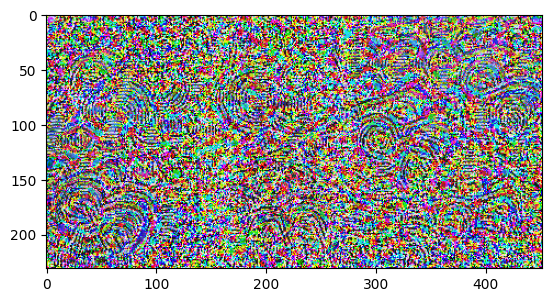

In [20]:
plt.imshow(np.uint8(trigger_patch['patch'][0].cpu().numpy().transpose(1, 2, 0)*255))

tensor(533.7772)